0. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

0. Import Datasets

In [2]:
dayEvents = pd.read_csv('./dataset/cleaned_dayEvents.csv')
goldPrice = pd.read_csv('./dataset/cleaned_GoldPrice.csv')

In [3]:
dayEvents.head()

,Sl. No,Name of Incident,Day,Month,Year,Country,Type of Event,Place Name,Impact,Affected Population,Important Person/Group Responsible,Outcome,Date
0,11,PokhranUnknownII Nuclear Tests,1,5,1998,India,Nuclear & WMD,Pokhran,India declared itself a nuclear state,International community,Atal Bihari Vajpayee,Mixed,1998-05-01
1,12,Mumbai Terror Attacks,1,11,2008,India,Terrorism & Violence,Mumbai,Highlighted the threat of international terrorism,Citizens of Mumbai,LashkarUnknowneUnknownTaiba,Negative,2008-11-01
2,18,Operation Blue Star,1,6,1984,India,Military & Conflict,Amritsar,Removal of armed militants from Golden Temple ...,Sikh community,"Indian Government, Sikh militants",Negative,1984-06-01
3,19,Kargil War,1,5,1999,India,Military & Conflict,"Kargil, Ladakh",India regained control of Kargil; heightened p...,Indian Armed Forces,"Indian Government, Pakistani Military",Positive,1999-05-01
4,20,Right to Information Act Enacted,1,6,2005,India,Legal & Legislation,India,Empowered citizens to seek information from pu...,Indian citizens,Government of India,Positive,2005-06-01


In [4]:
goldPrice.head()

,Date,Price(USD),Price(THB)
0,1979-01-01,233.7,4511.3
1,1979-02-01,251.3,4985.7
2,1979-03-01,240.1,4812.9
3,1979-04-01,245.3,4891.0
4,1979-05-01,274.6,5560.8


In [5]:
dayEvents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386 entries, 0 to 385
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Sl. No                              386 non-null    int64 
 1   Name of Incident                    386 non-null    object
 2   Day                                 386 non-null    int64 
 3   Month                               386 non-null    int64 
 4   Year                                386 non-null    int64 
 5   Country                             386 non-null    object
 6   Type of Event                       386 non-null    object
 7   Place Name                          386 non-null    object
 8   Impact                              386 non-null    object
 9   Affected Population                 386 non-null    object
 10  Important Person/Group Responsible  386 non-null    object
 11  Outcome                             386 non-null    object

In [6]:
# Change Type to Date datatype
dayEvents['Date'] = pd.to_datetime(dayEvents['Date'])
goldPrice['Date'] = pd.to_datetime(goldPrice['Date'])

In [7]:
dayEvents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386 entries, 0 to 385
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Sl. No                              386 non-null    int64         
 1   Name of Incident                    386 non-null    object        
 2   Day                                 386 non-null    int64         
 3   Month                               386 non-null    int64         
 4   Year                                386 non-null    int64         
 5   Country                             386 non-null    object        
 6   Type of Event                       386 non-null    object        
 7   Place Name                          386 non-null    object        
 8   Impact                              386 non-null    object        
 9   Affected Population                 386 non-null    object        
 10  Important Person/Group Res

New Column - Gold Change %
- Old Price - New Price / New Price จะได้ % เป็น Price อันใหม่ที่เปลี่ยนไปกี่ %

In [8]:
goldPrice["Gold Change %"] = goldPrice["Price(USD)"].pct_change() * 100

Sort Date by Month and Year

In [9]:
dayEvents = dayEvents.sort_values(['Year','Month'])

In [10]:
dayEvents.head()

,Sl. No,Name of Incident,Day,Month,Year,Country,Type of Event,Place Name,Impact,Affected Population,Important Person/Group Responsible,Outcome,Date
192,609,1979 Iranian Revolution,1,2,1979,Iran,Political,Iran,"Establishment of the Islamic Republic of Iran,...",Iranian citizens,Ayatollah Khomeini,Mixed,1979-02-01
76,174,OneUnknownChild Policy Introduced,1,9,1979,China,Political,Nationwide,Aimed to control the rapidly growing populatio...,Chinese families,Chinese government,Mixed,1979-09-01
187,531,Speak Mandarin Campaign Launched,1,9,1979,Singapore,Cultural & Religious,Singapore,Promotion of Mandarin over other Chinese diale...,Chinese Singaporeans,Singaporean Government,Positive,1979-09-01
173,499,Juhayman alUnknownOtaybi's Seizure of the Gran...,1,11,1979,Saudi Arabia,Terrorism & Violence,Mecca,A twoUnknownweek siege that challenged the Sau...,"Saudi Arabian citizens, pilgrims",Juhayman alUnknownOtaybi,Negative,1979-11-01
96,245,SovietUnknownAfghan War,1,12,1979,USSR,Military & Conflict,Afghanistan,A costly and ultimately unsuccessful attempt b...,Afghan and Soviet citizens,Leonid Brezhnev,Negative,1979-12-01


Merge Data

In [11]:
df = dayEvents.merge(
    goldPrice,
    on="Date",
    how="left"
).dropna()

In [12]:
df["Gold Change %"].describe()

count    384.000000
mean       0.811572
std        5.305843
min      -17.377049
25%       -2.223720
50%        0.455270
75%        3.487682
max       27.539062
Name: Gold Change %, dtype: float64

In [13]:
df["Gold Change %"].value_counts().head()

Gold Change %
-1.260860    5
 7.091796    5
 0.787278    5
-4.205607    4
 1.961447    4
Name: count, dtype: int64

In [14]:
df.head()

,Sl. No,Name of Incident,Day,Month,Year,Country,Type of Event,Place Name,Impact,Affected Population,Important Person/Group Responsible,Outcome,Date,Price(USD),Price(THB),Gold Change %
0,609,1979 Iranian Revolution,1,2,1979,Iran,Political,Iran,"Establishment of the Islamic Republic of Iran,...",Iranian citizens,Ayatollah Khomeini,Mixed,1979-02-01,251.3,4985.7,7.531023
1,174,OneUnknownChild Policy Introduced,1,9,1979,China,Political,Nationwide,Aimed to control the rapidly growing populatio...,Chinese families,Chinese government,Mixed,1979-09-01,397.3,7894.9,26.086957
2,531,Speak Mandarin Campaign Launched,1,9,1979,Singapore,Cultural & Religious,Singapore,Promotion of Mandarin over other Chinese diale...,Chinese Singaporeans,Singaporean Government,Positive,1979-09-01,397.3,7894.9,26.086957
3,499,Juhayman alUnknownOtaybi's Seizure of the Gran...,1,11,1979,Saudi Arabia,Terrorism & Violence,Mecca,A twoUnknownweek siege that challenged the Sau...,"Saudi Arabian citizens, pilgrims",Juhayman alUnknownOtaybi,Negative,1979-11-01,415.7,8260.5,8.821990
4,245,SovietUnknownAfghan War,1,12,1979,USSR,Military & Conflict,Afghanistan,A costly and ultimately unsuccessful attempt b...,Afghan and Soviet citizens,Leonid Brezhnev,Negative,1979-12-01,512.0,10645.2,23.165745


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 384 entries, 0 to 383
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Sl. No                              384 non-null    int64         
 1   Name of Incident                    384 non-null    object        
 2   Day                                 384 non-null    int64         
 3   Month                               384 non-null    int64         
 4   Year                                384 non-null    int64         
 5   Country                             384 non-null    object        
 6   Type of Event                       384 non-null    object        
 7   Place Name                          384 non-null    object        
 8   Impact                              384 non-null    object        
 9   Affected Population                 384 non-null    object        
 10  Important Person/Group Responsi

Plot graph

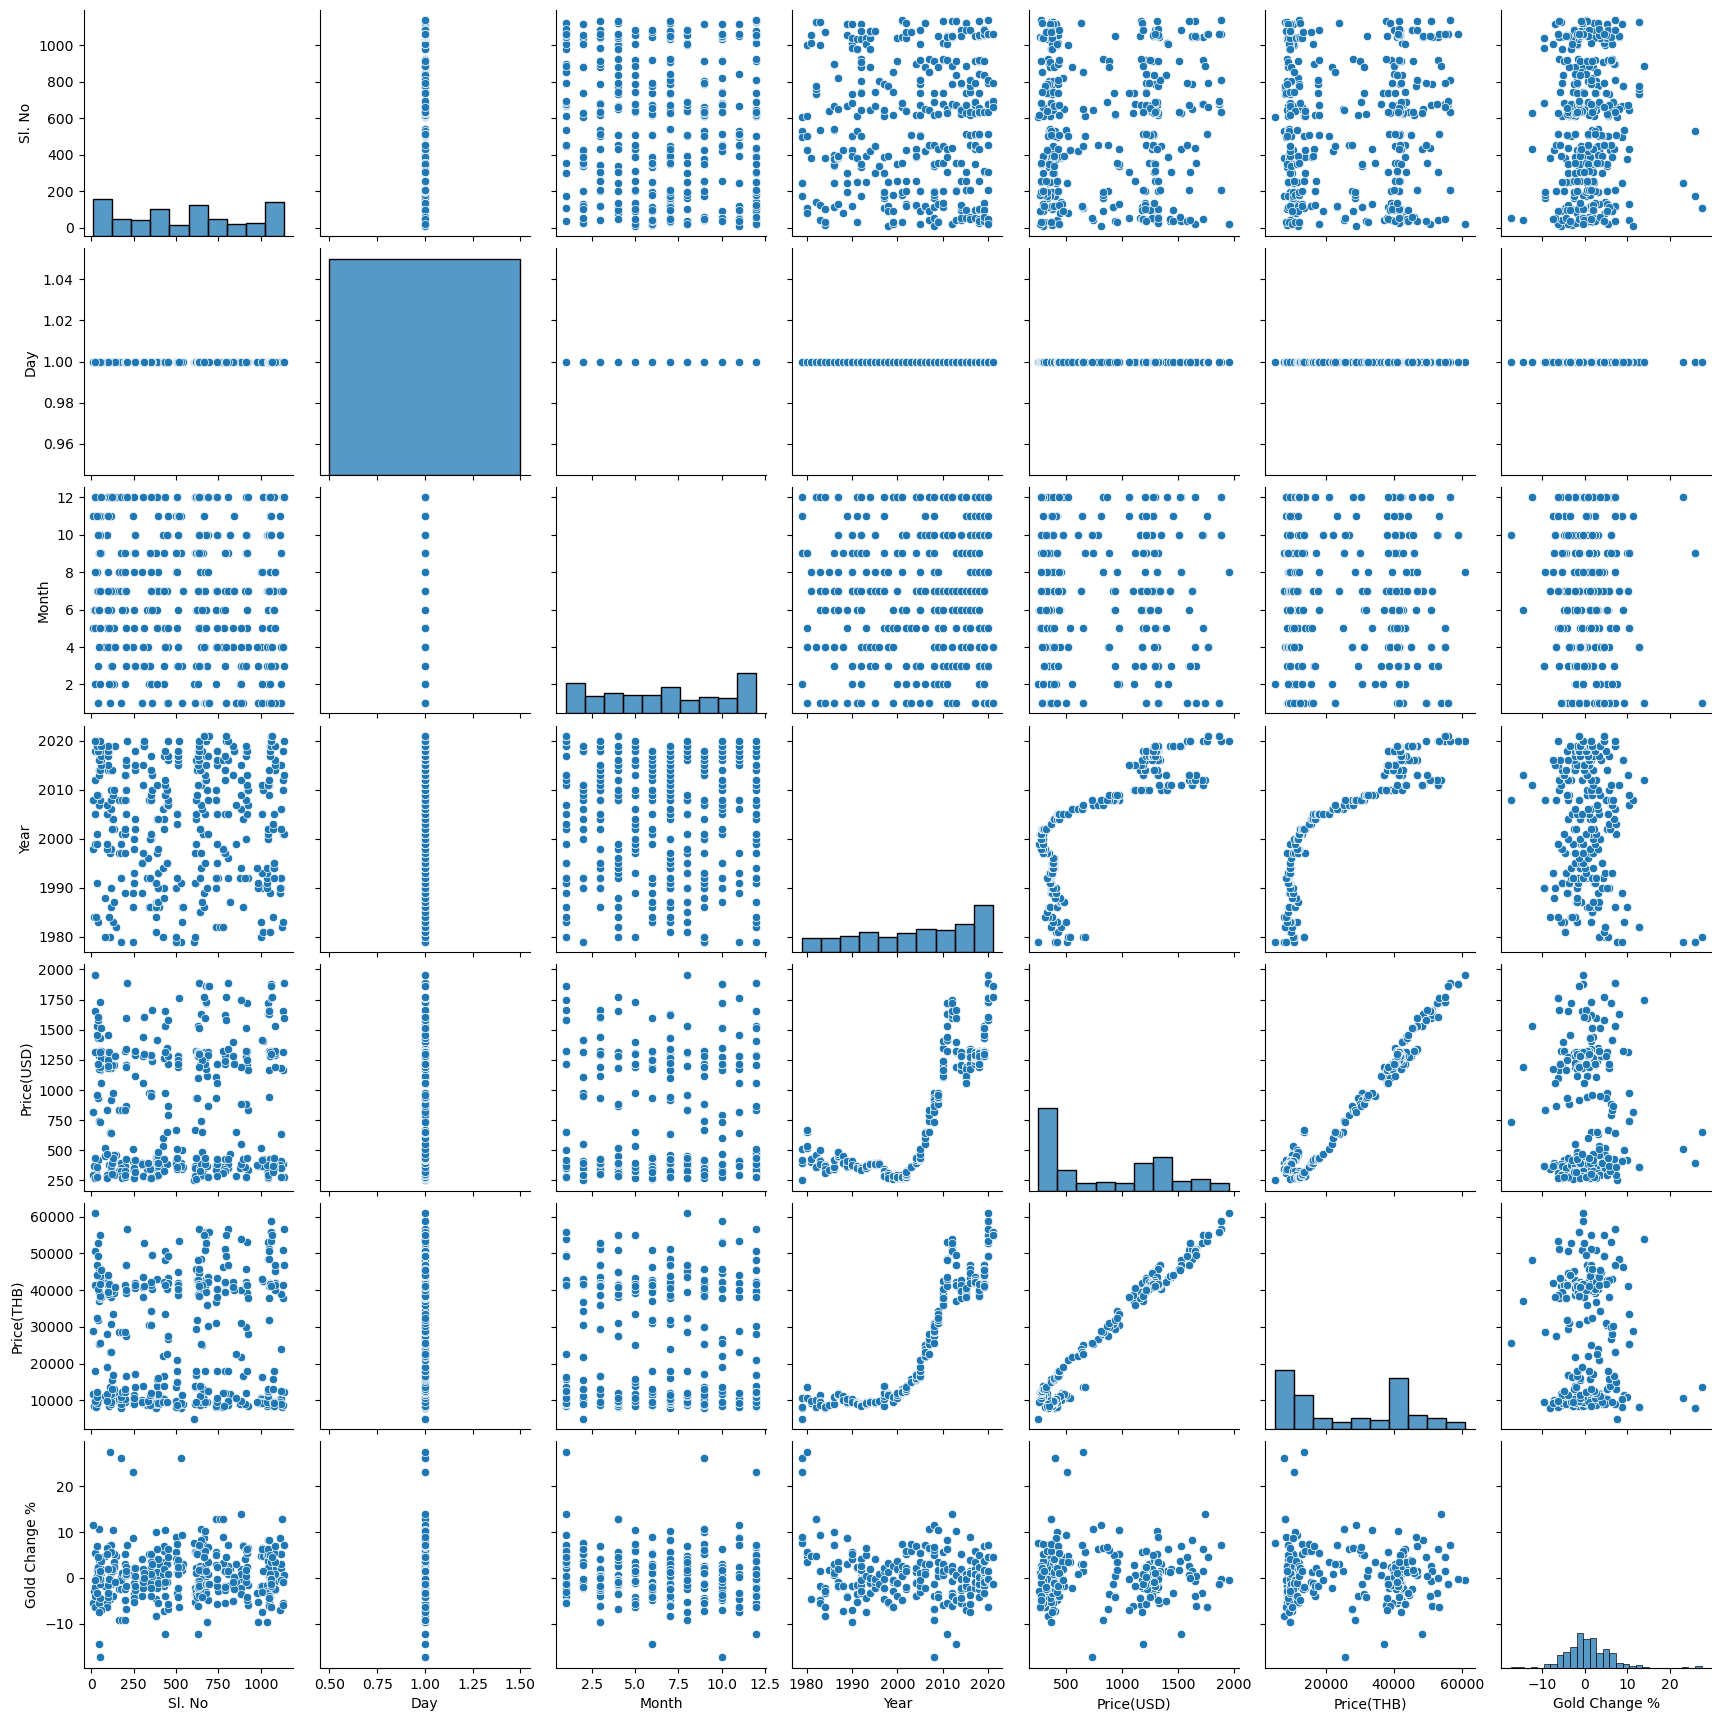

In [16]:
sns.pairplot(df)

In [17]:
df.describe()

,Sl. No,Day,Month,Year,Date,Price(USD),Price(THB),Gold Change %
count,384.000000,384.0,384.000000,384.000000,384,384.000000,384.000000,384.000000
mean,553.257812,1.0,6.648438,2004.286458,2004-10-03 03:45:00,849.783854,26972.126042,0.811572
min,11.000000,1.0,1.000000,1979.000000,1979-02-01 00:00:00,251.300000,4985.700000,-17.377049
25%,236.000000,1.0,4.000000,1993.000000,1993-10-16 18:00:00,368.475000,10382.225000,-2.223720
50%,574.000000,1.0,7.000000,2007.000000,2007-01-01 00:00:00,666.800000,24439.200000,0.455270
75%,844.500000,1.0,10.000000,2016.000000,2016-04-01 00:00:00,1291.000000,41711.375000,3.487682
max,1137.000000,1.0,12.000000,2021.000000,2021-04-01 00:00:00,1957.400000,60917.600000,27.539062
std,351.887686,0.0,3.463928,12.281988,NaN,513.982149,16521.794923,5.305843
